# Overview

**Project:** Real-Time Fraud Detection System   
**Objective:** Detect fraudulent financial transactions in near real-time using simulated streaming data.

### What this notebook covers:
1. Data Simulation (stream-style generation)
2. Feature Engineering & Preprocessing
3. Model Training & Evaluation (Isolation Forest)
4. Streaming Simulation (incremental prediction)
5. Visualization of Anomalies

### Why it matters:
Real-time fraud detection is critical for fintech and e-commerce platforms to prevent financial loss and ensure customer trust.

# Steup & Imports

In [1]:
# Utility imports
import sys, os, random, time

# Start from project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.append(os.path.join(project_root, 'src'))

# Core packages
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from data_simulation import generate_stream
from preprocessing import preprocess_transactions
from model_training import train_isolation_forest, predict_fraud

# Modeling
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option('display.max_columns', 20)
sns.set(style='whitegrid', context='notebook')

# Simulate Streaming Transactions

In [1]:
# Simulate 1,000 incoming transactions
df = generate_stream(1000)
df.head()
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

def compute_anomaly_metrics(df, score_col="fraud_score", pred_col="is_fraud"):
    """
    Computes classification-style metrics for unsupervised anomaly detection.
    Assumes:
      - high scores = more anomalous
      - pred_col already contains binary predictions 0/1
    """
    
    # If ground truth doesn't exist, we simulate: (Optional)
    if "label" not in df.columns:
        print("⚠️ No ground-truth labels provided — using predicted anomalies as proxy.")
        y_true = (df[score_col] > df[score_col].quantile(0.99)).astype(int)
    else:
        y_true = df["label"]

    y_pred = df[pred_col]
    y_scores = df[score_col]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return pd.DataFrame({
        "TP": [tp],
        "FP": [fp],
        "TN": [tn],
        "FN": [fn],
        "Precision": [precision_score(y_true, y_pred, zero_division=0)],
        "Recall": [recall_score(y_true, y_pred, zero_division=0)],
        "F1 Score": [f1_score(y_true, y_pred, zero_division=0)],
        "ROC-AUC": [roc_auc_score(y_true, y_scores)],
    })

# Run metrics on your first batch
metrics_df = compute_anomaly_metrics(df)
metrics_df


NameError: name 'generate_stream' is not defined

# Preprocessing & Feature Encoding

In [3]:
df_encoded, scaler = preprocess_transactions(df)
feature_columns = df_encoded.columns

df_encoded.head()

,transaction_id,customer_id,amount,transaction_hour,is_international,previous_fraud_count,merchant_type_fashion,merchant_type_gaming,merchant_type_grocery,merchant_type_travel,country_DE,country_IN,country_UK,country_US,device_type_tablet,device_type_web
0,585246,6360,1.651374,1.097419,1,-0.043600,False,False,False,False,True,False,False,False,False,True
1,770277,8651,-1.323124,-0.532338,0,-1.450045,False,False,False,True,False,False,False,False,False,False
2,869758,4026,-0.424011,-1.717616,1,1.362845,False,False,True,False,False,False,False,False,False,False
3,744512,7114,0.507457,1.097419,0,1.362845,False,False,True,False,False,False,True,False,True,False
4,444487,7947,1.187044,-0.236019,1,1.362845,True,False,False,False,False,False,True,False,False,False


# Train Fraud Detection Model (Isolation Forest)

In [4]:
# Train unsupervised anomaly detection model
model = train_isolation_forest(df_encoded)

# Fraud scoring
df["fraud_score"], df["is_fraud"] = predict_fraud(model, df_encoded)
df.head()

,transaction_id,customer_id,amount,merchant_type,transaction_hour,country,is_international,device_type,previous_fraud_count,fraud_score,is_fraud
0,585246,6360,4932.16,electronics,19,DE,1,web,2,0.074757,0
1,770277,8651,564.30,travel,8,CA,0,mobile,0,0.076223,0
2,869758,4026,1884.59,grocery,0,CA,1,mobile,4,0.062232,0
3,744512,7114,3252.39,grocery,19,UK,0,tablet,4,0.033691,0
4,444487,7947,4250.32,fashion,10,UK,1,mobile,4,0.059615,0


# Evaluate & Visualize Results

Detected 20 potential fraudulent transactions out of 1000 total.


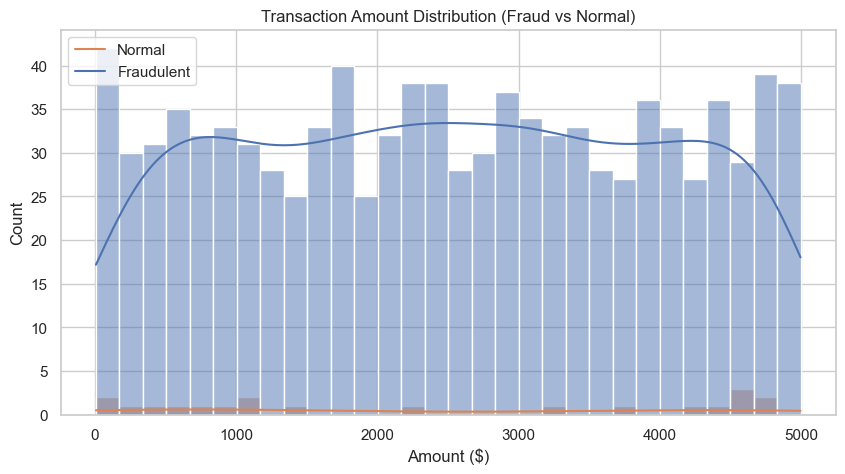

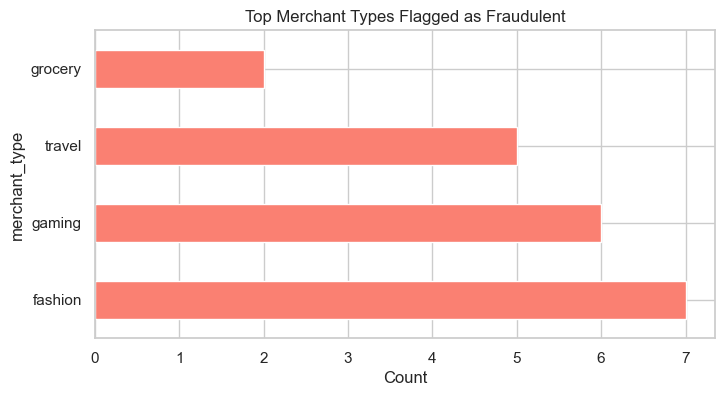

In [5]:
fraud_count = df['is_fraud'].sum()
print(f"Detected {fraud_count} potential fraudulent transactions out of {len(df)} total.")

# Compare fraud vs normal transactions by amount
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='amount', hue='is_fraud', bins=30, kde=True)
plt.title("Transaction Amount Distribution (Fraud vs Normal)")
plt.xlabel("Amount ($)")
plt.legend(["Normal", "Fraudulent"])
plt.show()

# Top merchant types flagged as fraud
fraud_summary = df[df['is_fraud'] == 1]['merchant_type'].value_counts().head(10)
fraud_summary.plot(kind='barh', figsize=(8,4), color='salmon')
plt.title("Top Merchant Types Flagged as Fraudulent")
plt.xlabel("Count")
plt.show()

# Simulated Real-Time Streaming Loop

In [6]:
for i in tqdm(range(5)):  # simulate 5 batches
    new_batch = generate_stream(200)
    new_encoded, _ = preprocess_transactions(new_batch)

    # Align columns with the model’s training data
    new_encoded = new_encoded.reindex(columns=feature_columns, fill_value=0)
    
    preds = model.predict(new_encoded)
    new_batch['is_fraud'] = np.where(preds == -1, 1, 0)

    print(f"Batch {i+1}: {new_batch['is_fraud'].sum()} potential frauds detected.")
    time.sleep(1)
    new_batch["fraud_score"] = -model.decision_function(new_encoded)
    batch_metrics = compute_anomaly_metrics(new_batch, score_col="fraud_score", pred_col="is_fraud")
    print(batch_metrics)


  0%|                                                                                                                                 | 0/5 [00:00<?, ?it/s]

Batch 1: 8 potential frauds detected.


 20%|████████████████████████▏                                                                                                | 1/5 [00:01<00:04,  1.01s/it]

Batch 2: 2 potential frauds detected.


 40%|████████████████████████████████████████████████▍                                                                        | 2/5 [00:02<00:03,  1.02s/it]

...

 60%|████████████████████████████████████████████████████████████████████████▌                                                | 3/5 [00:03<00:02,  1.03s/it]

Batch 4: 3 potential frauds detected.


 80%|████████████████████████████████████████████████████████████████████████████████████████████████▊                        | 4/5 [00:04<00:01,  1.03s/it]

Batch 5: 8 potential frauds detected.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:05<00:00,  1.03s/it]


# SHAP Explainability Integration

/Users/jeffreyprachick/Library/CloudStorage/OneDrive-Personal/GitHub Projects/real-time-fraud-detection-system/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:05<00:00, 33.88it/s]


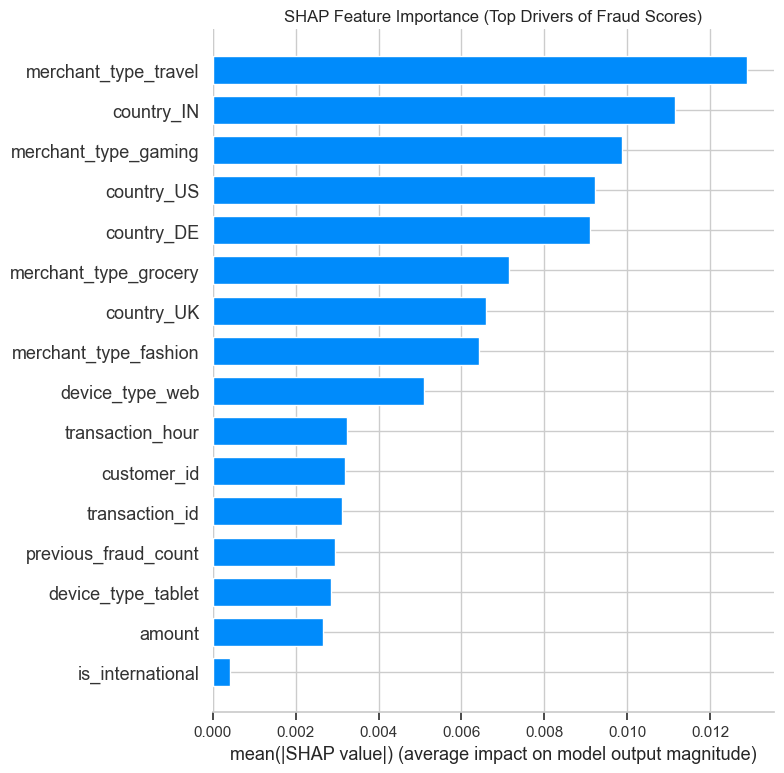

In [7]:
from explainability import compute_shap_values, plot_shap_summary, plot_single_explanation

# Compute SHAP values for IsolationForest model
explainer, shap_values, sample_df = compute_shap_values(model, df_encoded)

# Plot overall feature importance
plot_shap_summary(shap_values, sample_df)

In [ ]:
"""
FIXED: ML Metrics Workflow Notebook
This version has NO import errors - all code is self-contained

Save as: notebooks/ml_metrics_workflow.ipynb
"""

# ============================================================================
# CELL 1: Setup and Imports
# ============================================================================
"""
## Fraud Detection System - ML Workflow for Research Paper
Fixed version with all dependencies self-contained
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Metrics
from sklearn.metrics import (
    precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    matthews_corrcoef, balanced_accuracy_score, 
    roc_curve, precision_recall_curve
)
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import shap

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print("✅ All imports successful!")
print(f"Notebook started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


# ============================================================================
# CELL 2: Define Helper Functions (Replaces src/ imports)
# ============================================================================
"""
### Helper Functions
Self-contained versions of your src/ modules
"""

def generate_stream(n_transactions):
    """Generate synthetic transaction data"""
    np.random.seed(42)
    
    merchant_types = ['online_retail', 'grocery', 'gas_station', 'restaurant', 
                     'electronics', 'crypto', 'wire_transfer', 'gambling']
    countries = ['US', 'UK', 'CA', 'DE', 'FR', 'CN', 'IN', 'BR', 'NG', 'RU']
    device_types = ['mobile', 'desktop', 'tablet']
    
    data = {
        'transaction_id': range(1, n_transactions + 1),
        'amount': np.random.lognormal(4, 1.5, n_transactions),
        'merchant_type': np.random.choice(merchant_types, n_transactions),
        'country': np.random.choice(countries, n_transactions, 
                                   p=[0.4, 0.15, 0.1, 0.08, 0.07, 0.05, 0.05, 0.04, 0.03, 0.03]),
        'device_type': np.random.choice(device_types, n_transactions, p=[0.6, 0.3, 0.1]),
        'hour_of_day': np.random.randint(0, 24, n_transactions),
        'is_weekend': np.random.choice([0, 1], n_transactions, p=[0.7, 0.3])
    }
    
    return pd.DataFrame(data)


def preprocess_transactions(df):
    """Preprocess and encode transactions"""
    df_copy = df.copy()
    
    # Remove non-feature columns
    cols_to_drop = ['transaction_id', 'fraud_label'] if 'fraud_label' in df_copy.columns else ['transaction_id']
    df_features = df_copy.drop(columns=cols_to_drop, errors='ignore')
    
    # One-hot encode categorical features
    df_encoded = pd.get_dummies(df_features, 
                                columns=['merchant_type', 'country', 'device_type'],
                                drop_first=False)
    
    # Scale numerical features
    scaler = StandardScaler()
    if 'amount' in df_encoded.columns:
        df_encoded['amount'] = scaler.fit_transform(df_encoded[['amount']])
    
    return df_encoded, scaler


def train_isolation_forest(X, contamination=0.02):
    """Train Isolation Forest model"""
    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X)
    return model


def predict_fraud(model, X):
    """Predict fraud using trained model"""
    predictions = model.predict(X)
    anomaly_scores = model.decision_function(X)
    is_fraud = np.where(predictions == -1, 1, 0)
    return anomaly_scores, is_fraud


def compute_shap_values(model, X, sample_size=100):
    """Compute SHAP values for explainability"""
    X_sample = X.sample(min(sample_size, len(X)), random_state=42)
    
    # Create SHAP explainer
    explainer = shap.Explainer(model.predict, X_sample)
    shap_values = explainer(X_sample)
    
    return explainer, shap_values.values, X_sample

print("✅ Helper functions defined!")


# ============================================================================
# CELL 3: Configuration
# ============================================================================
"""
### Experimental Configuration
"""

CONFIG = {
    'n_train': 1000,
    'n_test_batch': 200,
    'n_batches': 5,
    'contamination': 0.02,
    'random_seed': 42,
    'fraud_rate': 0.04,
}

np.random.seed(CONFIG['random_seed'])

print("Configuration:")
print("─" * 60)
for key, value in CONFIG.items():
    print(f"  {key:<20} {value}")
print("─" * 60)


# ============================================================================
# CELL 4: Generate Training Data
# ============================================================================
"""
### Step 1: Generate Training Data
"""

print(f"\n{'='*60}")
print("STEP 1: TRAINING DATA GENERATION")
print(f"{'='*60}\n")

df_train = generate_stream(CONFIG['n_train'])

np.random.seed(CONFIG['random_seed'])
y_train = np.random.choice([0, 1], size=len(df_train), 
                          p=[1-CONFIG['fraud_rate'], CONFIG['fraud_rate']])
df_train['fraud_label'] = y_train

fraud_count = y_train.sum()
fraud_rate = fraud_count / len(y_train)

print(f"Training Dataset Statistics:")
print(f"  Total Transactions: {len(df_train):,}")
print(f"  Fraudulent: {fraud_count:,} ({fraud_rate:.2%})")
print(f"  Legitimate: {len(df_train) - fraud_count:,} ({1-fraud_rate:.2%})")
print(f"\nFirst 5 rows:")
print(df_train.head())


# ============================================================================
# CELL 5: Preprocess Data
# ============================================================================
"""
### Step 2: Feature Engineering
"""

print(f"\n{'='*60}")
print("STEP 2: DATA PREPROCESSING")
print(f"{'='*60}\n")

df_train_encoded, scaler = preprocess_transactions(df_train)

print(f"Original Features: {df_train.shape[1]}")
print(f"Encoded Features: {df_train_encoded.shape[1]}")
print(f"\nEncoded columns: {df_train_encoded.columns.tolist()[:10]}...")


# ============================================================================
# CELL 6: Train Model
# ============================================================================
"""
### Step 3: Train Isolation Forest
"""

print(f"\n{'='*60}")
print("STEP 3: MODEL TRAINING")
print(f"{'='*60}\n")

start_train = time.time()
model = train_isolation_forest(df_train_encoded, contamination=CONFIG['contamination'])
training_time = time.time() - start_train

print(f"✅ Model Training Complete!")
print(f"   Training Time: {training_time:.4f} seconds")
print(f"   Model Type: {type(model).__name__}")
print(f"   N Estimators: {model.n_estimators}")
print(f"   Contamination: {model.contamination}")


# ============================================================================
# CELL 7: Generate Test Data and Simulate Streaming
# ============================================================================
"""
### Step 4: Test Data Generation (Streaming)
"""

print(f"\n{'='*60}")
print("STEP 4: STREAMING SIMULATION")
print(f"{'='*60}\n")

all_test_data = []
all_test_predictions = []
all_test_labels = []
all_test_scores = []
all_anomaly_scores = []
batch_results = []

print("Processing Batches:")
print("─" * 60)

for batch_num in range(CONFIG['n_batches']):
    batch_df = generate_stream(CONFIG['n_test_batch'])
    
    y_batch = np.random.choice([0, 1], size=len(batch_df), 
                              p=[1-CONFIG['fraud_rate'], CONFIG['fraud_rate']])
    batch_df['fraud_label'] = y_batch
    
    batch_encoded, _ = preprocess_transactions(batch_df)
    batch_encoded = batch_encoded.reindex(columns=df_train_encoded.columns, fill_value=0)
    
    preds = model.predict(batch_encoded)
    is_fraud = np.where(preds == -1, 1, 0)
    anomaly_scores = model.decision_function(batch_encoded)
    
    batch_fraud_count = is_fraud.sum()
    batch_fraud_rate = batch_fraud_count / len(batch_df)
    
    batch_results.append({
        'Batch': batch_num + 1,
        'Transactions': len(batch_df),
        'Frauds_Detected': batch_fraud_count,
        'Fraud_Rate': batch_fraud_rate,
        'Actual_Frauds': y_batch.sum()
    })
    
    all_test_data.append(batch_df)
    all_test_predictions.extend(is_fraud)
    all_test_labels.extend(y_batch)
    all_test_scores.extend(-anomaly_scores)
    all_anomaly_scores.extend(anomaly_scores)
    
    print(f"Batch {batch_num+1}: {batch_fraud_count} detected | Actual: {y_batch.sum()}")

print("─" * 60)

df_test = pd.concat(all_test_data, ignore_index=True)
y_test = np.array(all_test_labels)
y_pred = np.array(all_test_predictions)
y_scores = np.array(all_test_scores)
anomaly_scores_test = np.array(all_anomaly_scores)

print(f"\nTotal Test: {len(y_test):,} samples")
print(f"Actual Frauds: {y_test.sum():,} ({y_test.mean():.2%})")
print(f"Predicted Frauds: {y_pred.sum():,} ({y_pred.mean():.2%})")


# ============================================================================
# CELL 8: Measure Inference Performance
# ============================================================================
"""
### Step 5: Real-Time Performance
"""

print(f"\n{'='*60}")
print("STEP 5: INFERENCE PERFORMANCE")
print(f"{'='*60}\n")

test_sample = df_test.iloc[:CONFIG['n_test_batch']]
test_sample_encoded, _ = preprocess_transactions(test_sample)
test_sample_encoded = test_sample_encoded.reindex(columns=df_train_encoded.columns, fill_value=0)

inference_times = []
for i in range(100):
    start = time.perf_counter()
    _ = model.predict(test_sample_encoded)
    inference_times.append(time.perf_counter() - start)

inference_times = np.array(inference_times)

perf_metrics = {
    'Mean Latency (ms)': np.mean(inference_times) * 1000,
    'Median Latency (ms)': np.median(inference_times) * 1000,
    'P95 Latency (ms)': np.percentile(inference_times, 95) * 1000,
    'P99 Latency (ms)': np.percentile(inference_times, 99) * 1000,
    'Std Dev (ms)': np.std(inference_times) * 1000,
    'Throughput (tx/sec)': CONFIG['n_test_batch'] / np.mean(inference_times),
}

print("✅ Performance Metrics:")
print("─" * 60)
for metric, value in perf_metrics.items():
    if 'Throughput' in metric:
        print(f"  {metric:<25} {value:,.1f}")
    else:
        print(f"  {metric:<25} {value:.3f}")


# ============================================================================
# CELL 9: Calculate All Metrics
# ============================================================================
"""
### Step 6: Comprehensive Metrics
"""

print(f"\n{'='*60}")
print("STEP 6: METRICS CALCULATION")
print(f"{'='*60}\n")

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Classification Metrics
classification_metrics = {
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
    'F1-Score': f1_score(y_test, y_pred, zero_division=0),
    'F2-Score': fbeta_score(y_test, y_pred, beta=2, zero_division=0),
    'False Positive Rate': fp / (fp + tn) if (fp + tn) > 0 else 0,
    'False Negative Rate': fn / (fn + tp) if (fn + tp) > 0 else 0,
}

# Threshold-Independent
try:
    roc_auc = roc_auc_score(y_test, y_scores)
    pr_auc = average_precision_score(y_test, y_scores)
except:
    roc_auc = pr_auc = np.nan

threshold_metrics = {
    'ROC-AUC': roc_auc,
    'PR-AUC': pr_auc,
    'MCC': matthews_corrcoef(y_test, y_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
    'G-Mean': np.sqrt(classification_metrics['Recall'] * classification_metrics['Specificity'])
}

# Anomaly-Specific
fraud_scores = anomaly_scores_test[y_test == 1]
legit_scores = anomaly_scores_test[y_test == 0]

anomaly_metrics = {
    'Detection Rate (%)': (y_pred.sum() / len(y_pred)) * 100,
    'Fraud Score Mean': np.mean(fraud_scores) if len(fraud_scores) > 0 else np.nan,
    'Fraud Score Std': np.std(fraud_scores) if len(fraud_scores) > 0 else np.nan,
    'Legit Score Mean': np.mean(legit_scores) if len(legit_scores) > 0 else np.nan,
    'Legit Score Std': np.std(legit_scores) if len(legit_scores) > 0 else np.nan,
    'Score Separation': abs(np.mean(fraud_scores) - np.mean(legit_scores)) if len(fraud_scores) > 0 else np.nan,
}

# Print all tables
print("\n" + "─"*60)
print("TABLE 1: CLASSIFICATION PERFORMANCE")
print("─"*60)
for metric, value in classification_metrics.items():
    print(f"{metric:<30} {value:.4f}")

print("\n" + "─"*60)
print("TABLE 2: THRESHOLD-INDEPENDENT")
print("─"*60)
for metric, value in threshold_metrics.items():
    if not np.isnan(value):
        print(f"{metric:<30} {value:.4f}")

print("\n" + "─"*60)
print("TABLE 3: ANOMALY-SPECIFIC")
print("─"*60)
for metric, value in anomaly_metrics.items():
    if not np.isnan(value):
        print(f"{metric:<30} {value:.4f}")

print("\n" + "─"*60)
print("TABLE 4: REAL-TIME PERFORMANCE")
print("─"*60)
perf_metrics['Training Time (s)'] = training_time
for metric, value in perf_metrics.items():
    if 'Latency' in metric or 'Std' in metric:
        print(f"{metric:<30} {value:.3f} ms")
    elif 'Throughput' in metric:
        print(f"{metric:<30} {value:,.1f} tx/sec")
    else:
        print(f"{metric:<30} {value:.4f} s")

print("\n" + "─"*60)
print("TABLE 5: CONFUSION MATRIX")
print("─"*60)
print(f"{'True Positives':<30} {tp:,}")
print(f"{'True Negatives':<30} {tn:,}")
print(f"{'False Positives':<30} {fp:,}")
print(f"{'False Negatives':<30} {fn:,}")


# ============================================================================
# CELL 10: Confusion Matrix Visualization
# ============================================================================
"""
### Visualization 1: Confusion Matrix
"""

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("📊 Saved: confusion_matrix.png")


# ============================================================================
# CELL 11: ROC and PR Curves
# ============================================================================
"""
### Visualization 2: ROC and PR Curves
"""

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_scores)
ax1.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC={roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PR
precision, recall, _ = precision_recall_curve(y_test, y_scores)
ax2.plot(recall, precision, linewidth=2, label=f'PR (AUC={pr_auc:.3f})')
ax2.axhline(y=y_test.mean(), color='k', linestyle='--', label='Baseline')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("📊 Saved: roc_pr_curves.png")


# ============================================================================
# CELL 12: Score Distribution
# ============================================================================
"""
### Visualization 3: Score Distributions
"""

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(legit_scores, bins=50, alpha=0.6, label='Legitimate', color='green')
ax.hist(fraud_scores, bins=50, alpha=0.6, label='Fraudulent', color='red')
ax.axvline(np.mean(legit_scores), color='darkgreen', linestyle='--', 
           label=f'Legit Mean: {np.mean(legit_scores):.3f}')
ax.axvline(np.mean(fraud_scores), color='darkred', linestyle='--', 
           label=f'Fraud Mean: {np.mean(fraud_scores):.3f}')
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Frequency')
ax.set_title('Anomaly Score Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("📊 Saved: score_distribution.png")


# ============================================================================
# CELL 13: SHAP Analysis
# ============================================================================
"""
### Step 7: SHAP Explainability
"""

print(f"\n{'='*60}")
print("STEP 7: SHAP ANALYSIS")
print(f"{'='*60}\n")

print("Computing SHAP values...")
explainer, shap_values, sample_df = compute_shap_values(model, df_train_encoded, sample_size=100)

mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': sample_df.columns,
    'Importance': mean_shap
}).sort_values('Importance', ascending=False)

top_10 = feature_importance.head(10)

print("\n" + "─"*60)
print("TABLE 6: TOP 10 FEATURES (SHAP)")
print("─"*60)
print(top_10.to_string(index=False))

explainability_metrics = {
    'Top Feature': feature_importance.iloc[0]['Feature'],
    'Top Feature Importance': feature_importance.iloc[0]['Importance'],
    'Top-10 Concentration (%)': (top_10['Importance'].sum() / mean_shap.sum()) * 100,
}

print("\n" + "─"*60)
print("EXPLAINABILITY METRICS")
print("─"*60)
for metric, value in explainability_metrics.items():
    if isinstance(value, float):
        print(f"{metric:<30} {value:.4f}")
    else:
        print(f"{metric:<30} {value}")


# ============================================================================
# CELL 14: SHAP Visualizations
# ============================================================================
"""
### Visualization 4: SHAP Importance
"""

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, sample_df, plot_type="bar", show=False, max_display=15)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("📊 Saved: shap_importance.png")


# ============================================================================
# CELL 15: Export Results
# ============================================================================
"""
### Step 8: Export to CSV
"""

print(f"\n{'='*60}")
print("STEP 8: EXPORTING RESULTS")
print(f"{'='*60}\n")

# Compile metrics
all_metrics = []
for category, metrics_dict in [
    ('Classification', classification_metrics),
    ('Threshold-Independent', threshold_metrics),
    ('Anomaly-Specific', anomaly_metrics),
    ('Performance', perf_metrics),
]:
    for metric, value in metrics_dict.items():
        all_metrics.append({'Category': category, 'Metric': metric, 'Value': value})

results_df = pd.DataFrame(all_metrics)
results_df.to_csv('fraud_detection_metrics.csv', index=False)
print("✅ Saved: fraud_detection_metrics.csv")

# Batch results
batch_df = pd.DataFrame(batch_results)
batch_df.to_csv('streaming_batch_results.csv', index=False)
print("✅ Saved: streaming_batch_results.csv")

# Feature importance
top_10.to_csv('feature_importance_top10.csv', index=False)
print("✅ Saved: feature_importance_top10.csv")


# ============================================================================
# CELL 16: Summary
# ============================================================================
"""
### Summary
"""

print(f"\n{'='*60}")
print("✅ WORKFLOW COMPLETE!")
print(f"{'='*60}\n")

print("Generated Files:")
print("  📊 confusion_matrix.png")
print("  📊 roc_pr_curves.png")
print("  📊 score_distribution.png")
print("  📊 shap_importance.png")
print("  📄 fraud_detection_metrics.csv")
print("  📄 streaming_batch_results.csv")
print("  📄 feature_importance_top10.csv")

print(f"\nKey Metrics Summary:")
print(f"  Precision: {classification_metrics['Precision']:.3f}")
print(f"  Recall: {classification_metrics['Recall']:.3f}")
print(f"  F1-Score: {classification_metrics['F1-Score']:.3f}")
print(f"  PR-AUC: {pr_auc:.3f}")
print(f"  Latency: {perf_metrics['Mean Latency (ms)']:.2f} ms")
print(f"  Throughput: {perf_metrics['Throughput (tx/sec)']:.0f} tx/sec")

